# 05 · Evaluación (§4.3: GroupKFold y test out-of-time)

La configuración final quedó fijada en `04_modelado/modelo_final.json` (ensemble por promedio, 6 variables,
hiperparámetros y ventana por miembro). Aquí no se toma ninguna decisión de modelado; solo se mide:

1. **Verificación complementaria con GroupKFold** por `id_vendedor` sobre el pool de desarrollo: ninguna vendedora
   queda a la vez en entrenamiento y validación. Se contrasta con una validación estratificada sin grupos para ver
   cuánto del desempeño depende de patrones individuales (memorización) y cuánto de patrones transferibles.
2. **Test OOT, una sola vez**: se entrenan los miembros con todo el pool de desarrollo y se predice el OOT
   (últimos 4 meses, brecha de 6 m). Métricas: AUC-ROC (principal), PR-AUC, curva ROC, matriz de confusión,
   precisión / recall / lift por % de base contactada y lift del decil superior mes a mes.

In [1]:
import sys, json, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, confusion_matrix
from src import datos, particion, evaluacion, modelos
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

df = datos.load()
spec = json.loads((Path.cwd().parent / "04_modelado/modelo_final.json").read_text())
dev_mask, oot_mask = particion.oot_split(df.mes_rank)
dev = df[dev_mask].reset_index(drop=True)
oot = df[oot_mask].reset_index(drop=True)
folds = particion.temporal_folds(dev.mes_rank)
FINAL = spec["final"]
print(f"modelo final: {FINAL['config']} ({FINAL['n_vars']} variables) | AUC selección {FINAL['auc']:.4f}, lift {FINAL['lift10']:.2f}")
print(f"desarrollo: {len(dev):,} filas ({dev.mes_obs.min():%Y-%m} → {dev.mes_obs.max():%Y-%m}) | "
      f"OOT: {len(oot):,} filas ({oot.mes_obs.min():%Y-%m} → {oot.mes_obs.max():%Y-%m}), churn {oot.churn.mean():.3f}")
for a in FINAL["miembros"]:
    c = spec["candidatos"][a]
    print(f"  - {a}: {len(c['variables'])} vars, ventana {c['ventana']}, w={c['params']['w']:.2f}")

modelo final: lightgbm+xgboost+catboost (6 variables) | AUC selección 0.7912, lift 2.34
desarrollo: 29,183 filas (2016-12 → 2025-05) | OOT: 879 filas (2025-12 → 2026-03), churn 0.276
  - lightgbm: 6 vars, ventana todo, w=1.08
  - xgboost: 6 vars, ventana todo, w=1.21
  - catboost: 6 vars, ventana todo, w=1.05


## 1 · Verificación con GroupKFold por vendedora

5 particiones sobre el pool de desarrollo. **GroupKFold**: cada vendedora en un solo fold. **StratifiedKFold** (sin
grupos): la misma vendedora puede aparecer en train y validación en meses distintos, como ocurre en la validación
temporal y en despliegue. Si ambos AUC coinciden, el modelo no depende de memorizar vendedoras.

In [2]:
def cv_auc(splitter, grupos=None):
    aucs, oof = [], np.full(len(dev), np.nan)
    for tr, va in splitter.split(dev, dev.churn, groups=grupos):
        ens = modelos.desde_spec(spec).fit(dev.iloc[tr], dev.churn.iloc[tr])
        oof[va] = ens.predict_proba(dev.iloc[va])[:, 1]
        aucs.append(roc_auc_score(dev.churn.iloc[va], oof[va]))
    return {"aucs": [round(a, 4) for a in aucs], "auc": float(np.mean(aucs)), "std": float(np.std(aucs)),
            "lift10": evaluacion.lift_decil_mensual(dev.mes_obs, dev.churn, oof)}

gkf = cv_auc(GroupKFold(n_splits=5), grupos=dev.id_vendedor)
skf = cv_auc(StratifiedKFold(n_splits=5, shuffle=True, random_state=42))
ver = pd.DataFrame({
    "temporal 4 bloques (selección, 04)": {"auc": FINAL["auc"], "std": np.std(spec["ensembles"][FINAL["config"]]["aucs"]),
                                           "lift10": FINAL["lift10"], "folds": str(spec["ensembles"][FINAL["config"]]["aucs"])},
    "GroupKFold(5) por vendedora": {"auc": gkf["auc"], "std": gkf["std"], "lift10": gkf["lift10"], "folds": str(gkf["aucs"])},
    "StratifiedKFold(5) sin grupos": {"auc": skf["auc"], "std": skf["std"], "lift10": skf["lift10"], "folds": str(skf["aucs"])},
}).T
ver[["auc", "std", "lift10"]] = ver[["auc", "std", "lift10"]].astype(float).round(4)
print(f"GroupKFold − StratifiedKFold: {gkf['auc'] - skf['auc']:+.4f} de AUC")
ver

GroupKFold − StratifiedKFold: +0.0002 de AUC


,auc,std,lift10,folds
"temporal 4 bloques (selección, 04)",0.7912,0.0089,2.3440,"[0.8001, 0.7846, 0.7999, 0.7803]"
GroupKFold(5) por vendedora,0.7342,0.0041,2.0788,"[0.7278, 0.7332, 0.7407, 0.7344, 0.7351]"
StratifiedKFold(5) sin grupos,0.7340,0.0072,2.0804,"[0.7468, 0.7283, 0.7279, 0.7368, 0.7302]"


## 2 · Entrenamiento final con todo el pool de desarrollo

Cada miembro se entrena con su ventana (todos usan la historia completa) y se guarda en `models/` (no versionado).

In [3]:
ens = modelos.desde_spec(spec).fit(dev, dev.churn)
(datos.ROOT / "models").mkdir(exist_ok=True)
joblib.dump(ens, datos.ROOT / "models" / "ensemble_final.joblib")
print(f"entrenado con {len(dev):,} filas | variables: {ens.feats}")

entrenado con 29,183 filas | variables: ['compras_hist', 'n_prod_u12', 'monto_cv_u12', 'n_ped_u12', 'monto_u12', 'ticket_prom_u3']


## 3 · Test out-of-time (una sola evaluación)

In [4]:
y = oot.churn.to_numpy()
p_m = ens.proba_miembros(oot)
p = np.mean(list(p_m.values()), axis=0)
prev = y.mean()

auc, prauc = roc_auc_score(y, p), average_precision_score(y, p)
por_miembro = pd.DataFrame({a: {"auc": roc_auc_score(y, q), "pr_auc": average_precision_score(y, q)} for a, q in p_m.items()}).T
por_mes = oot.assign(p=p).groupby(oot.mes_obs.dt.strftime("%Y-%m")).apply(
    lambda g: pd.Series({"n": len(g), "churn": g.churn.mean(), "auc": roc_auc_score(g.churn, g.p),
                         "lift10": evaluacion.lift_decil_mensual(g.mes_obs, g.churn, g.p)}))
lift10_mensual = evaluacion.lift_decil_mensual(oot.mes_obs, oot.churn, p)
print(f"OOT  AUC={auc:.4f}  PR-AUC={prauc:.4f} (prevalencia {prev:.3f})  lift decil mensual={lift10_mensual:.2f}")
print(por_miembro.round(4)); print(); print(por_mes.round(4))

OOT  AUC=0.7926  PR-AUC=0.5681 (prevalencia 0.276)  lift decil mensual=2.27
             auc  pr_auc
lightgbm  0.7930  0.5733
xgboost   0.7939  0.5575
catboost  0.7897  0.5438

             n   churn     auc  lift10
mes_obs                               
2025-12  273.0  0.3114  0.7901  2.2601
2026-01  192.0  0.2708  0.7817  2.3320
2026-02  197.0  0.2640  0.7908  2.1933
2026-03  217.0  0.2488  0.8135  2.2963


In [5]:
# precisión / recall / lift por % de base contactada (OOT completo ordenado por score)
orden = np.argsort(-p); y_ord = y[orden]
rows = []
for pct in (5, 10, 15, 20, 25, 30, 40, 50):
    k = int(round(len(y) * pct / 100))
    top = y_ord[:k]
    rows.append({"pct_contactado": pct, "n": k, "precision": top.mean(), "recall": top.sum() / y.sum(),
                 "lift": top.mean() / prev})
contacto = pd.DataFrame(rows).set_index("pct_contactado")
contacto.round(3)

,n,precision,recall,lift
pct_contactado,,,,
5,44,0.659,0.119,2.384
10,88,0.625,0.226,2.261
15,132,0.644,0.350,2.329
20,176,0.591,0.428,2.137
25,220,0.573,0.519,2.072
30,264,0.545,0.593,1.973
40,352,0.486,0.704,1.757
50,440,0.464,0.840,1.677


In [6]:
def matriz(umbral_desc, yhat):
    tn, fp, fn, tp = confusion_matrix(y, yhat).ravel()
    return {"umbral": umbral_desc, "TP": tp, "FP": fp, "FN": fn, "TN": tn,
            "precision": tp / (tp + fp), "recall": tp / (tp + fn), "contactados_%": 100 * (tp + fp) / len(y)}
corte10 = np.sort(p)[::-1][int(round(len(y) * 0.10)) - 1]
mats = pd.DataFrame([matriz("p >= 0.5", (p >= 0.5).astype(int)),
                     matriz(f"decil superior (p >= {corte10:.3f})", (p >= corte10).astype(int))]).set_index("umbral")
mats.round(3)

,TP,FP,FN,TN,precision,recall,contactados_%
umbral,,,,,,,
p >= 0.5,130,98,113,538,0.570,0.535,25.939
decil superior (p >= 0.635),55,33,188,603,0.625,0.226,10.011


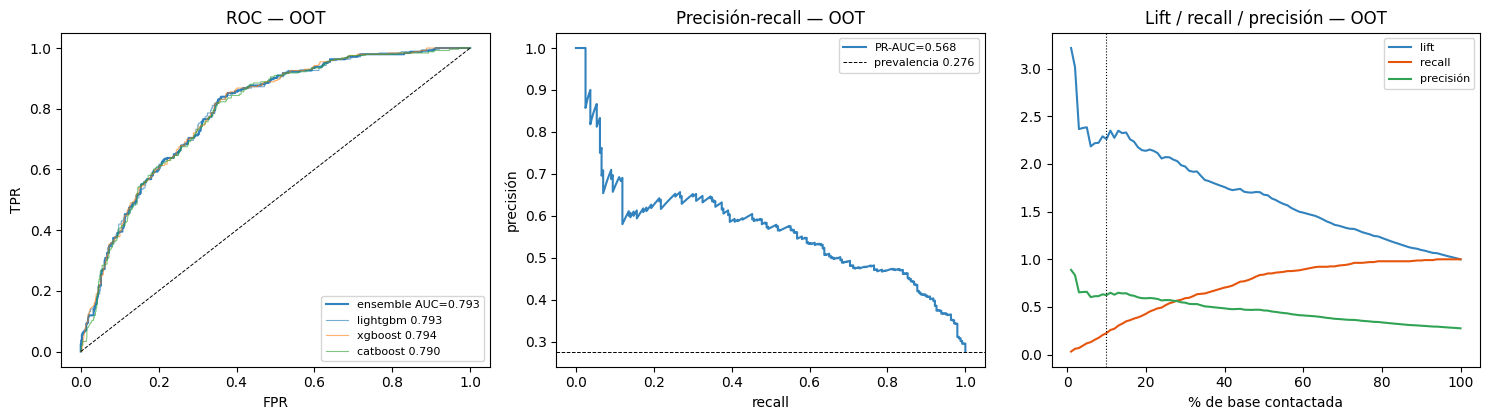

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
fpr, tpr, _ = roc_curve(y, p)
axes[0].plot(fpr, tpr, c="#3182bd", label=f"ensemble AUC={auc:.3f}")
for a, q in p_m.items():
    f_, t_, _ = roc_curve(y, q); axes[0].plot(f_, t_, lw=0.8, alpha=0.6, label=f"{a} {roc_auc_score(y, q):.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.7); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC — OOT"); axes[0].legend(fontsize=8)
pr, rc, _ = precision_recall_curve(y, p)
axes[1].plot(rc, pr, c="#3182bd", label=f"PR-AUC={prauc:.3f}"); axes[1].axhline(prev, c="k", ls="--", lw=0.7, label=f"prevalencia {prev:.3f}")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precisión"); axes[1].set_title("Precisión-recall — OOT"); axes[1].legend(fontsize=8)
pcts = np.arange(1, 101); ks = np.maximum(1, np.round(len(y) * pcts / 100).astype(int))
cum = np.cumsum(y_ord)
axes[2].plot(pcts, cum[ks - 1] / ks / prev, c="#3182bd", label="lift")
axes[2].plot(pcts, cum[ks - 1] / y.sum(), c="#e6550d", label="recall")
axes[2].plot(pcts, cum[ks - 1] / ks, c="#31a354", label="precisión")
axes[2].axvline(10, c="k", ls=":", lw=0.8); axes[2].set_xlabel("% de base contactada"); axes[2].set_title("Lift / recall / precisión — OOT"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4 · Exportación

In [8]:
res = {"fecha": pd.Timestamp.today().strftime("%Y-%m-%d"), "modelo": FINAL["config"], "n_vars": FINAL["n_vars"],
       "variables": ens.feats,
       "oot": {"desde": f"{oot.mes_obs.min():%Y-%m}", "hasta": f"{oot.mes_obs.max():%Y-%m}", "n": int(len(oot)),
               "prevalencia": float(prev), "auc": float(auc), "pr_auc": float(prauc),
               "lift10_mensual": float(lift10_mensual), "auc_por_miembro": por_miembro.auc.round(4).to_dict(),
               "por_mes": por_mes.round(4).to_dict(orient="index"),
               "contacto": contacto.round(4).to_dict(orient="index"), "matrices": mats.round(4).to_dict(orient="index")},
       "verificacion": {"temporal_4_bloques": FINAL["auc"], "groupkfold_5": gkf, "stratifiedkfold_5": skf}}
(Path.cwd() / "oot_metricas.json").write_text(json.dumps(res, indent=2, ensure_ascii=False, default=float))

texto = f"""# Evaluación (sem2)

Generado por `05_evaluacion/evaluacion.ipynb`. Modelo final: **{FINAL["config"]}** ({FINAL["n_vars"]} variables:
{", ".join(f"`{f}`" for f in ens.feats)}), según `04_modelado/modelo_final.json`.

## 1 · Verificación complementaria (pool de desarrollo, {len(dev):,} filas)
{ver.to_markdown()}

GroupKFold − StratifiedKFold: {gkf["auc"] - skf["auc"]:+.4f} de AUC.

## 2 · Test out-of-time (una sola evaluación)
OOT: {oot.mes_obs.min():%Y-%m} → {oot.mes_obs.max():%Y-%m}, {len(oot):,} filas, prevalencia {prev:.3f}.
Entrenamiento: todo el pool de desarrollo (hasta {dev.mes_obs.max():%Y-%m}, brecha de 6 meses).

| métrica | valor |
|---|---:|
| AUC-ROC | {auc:.4f} |
| PR-AUC | {prauc:.4f} |
| Lift decil superior (media mensual) | {lift10_mensual:.2f} |

Por miembro:
{por_miembro.round(4).to_markdown()}

Por mes:
{por_mes.round(4).to_markdown()}

Precisión / recall / lift por % de base contactada:
{contacto.round(3).to_markdown()}

Matrices de confusión:
{mats.round(3).to_markdown()}

Lectura: el AUC de selección (0.7912, 4 bloques de 2024-02 a 2025-05) y el AUC OOT ({auc:.4f}) difieren en
{auc - FINAL["auc"]:+.4f}; la diferencia combina el sesgo de selección y la dificultad propia del período.
Precisión y recall a p ≥ 0.5 dependen del umbral; para comparar modelos, la métrica es el AUC y, para campañas, el lift.
"""
(datos.ROOT / "reports" / "evaluacion.md").write_text(texto)
print("-> oot_metricas.json, models/ensemble_final.joblib, reports/evaluacion.md")

-> oot_metricas.json, models/ensemble_final.joblib, reports/evaluacion.md
